## Cell 1: Imports & Setup

In [1]:
import random
import os
import copy
import torch
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from dataclasses import dataclass, field
from typing import List, Optional, Dict, Union
from dotenv import load_dotenv
load_dotenv()
import matplotlib.pyplot as plt
import json
import time
import google.generativeai as genai
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns

# Mount Drive

# API Keys


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


## Cell 2: Configurations

In [2]:
@dataclass
class ExperimentConfig:
    # --- Model & Device ---
    model_name: str = "meta-llama/Llama-3.1-8B-Instruct"
    device_map: str = "auto"
    torch_dtype: torch.dtype = torch.bfloat16
    base_dir: str = "results_v1"

    # --- Input Data ---
    csv_file: str = "results_v1/Entities_QA.csv"
    mode: str = "train"

    # --- Extraction (Input to Adapter) ---
    extraction_layer: int = 16
    extraction_pos: str = "resid_post"
    normalize_vectors: bool = True

    # --- Injection (Output of Adapter) ---
    injection_layer: int = 16

    # --- Training Settings ---
    architecture_id: int = 3          # V3: residual bottleneck adapter
    train_ratio: float = 0.8
    seed: int = 42
    use_lowercase: bool = True

    # --- Phase 1: Weighted CE ---
    phase1_epochs: int = 20
    phase1_lr: float = 1e-3
    phase1_batch_size: int = 8
    phase1_dropout: float = 0.1
    entity_token_weight: float = 5.0  # Extra weight on entity tokens in CE loss

    # --- Phase 2: GRPO ---
    phase2_epochs: int = 5
    phase2_lr: float = 1e-4           # Lower LR — fine-tuning on top of phase 1
    phase2_batch_size: int = 4        # Smaller: each example generates G completions
    phase2_G: int = 4                 # Number of completions per example (group size)
    phase2_max_new_tokens: int = 64
    phase2_temperature: float = 0.8
    phase2_reward_entity_weight: float = 0.5   # Weight of entity-presence reward
    phase2_reward_rouge_weight: float = 0.5    # Weight of ROUGE-L reward
    phase2_kl_coef: float = 0.01              # KL regularization coefficient

    # --- Adapter Architecture (V3) ---
    adapter_bottleneck_dim: int = 512  # Bottleneck dim (much smaller than hidden_size)

    # --- Extraction Prompting ---
    prompt_id: int = 1
    concept_chat_template: List[Dict] = field(default_factory=lambda: [
        {"role": "user", "content": "Tell me about {word}"}
    ])

    # Placeholder — populated dynamically from CSV
    words: List[str] = field(default_factory=list)
    concept_prefix: Optional[str] = None

    def get_safe_model_name(self):
        return self.model_name.replace("/", "_")

    @property
    def cache_dir(self):
        path = os.path.join(self.base_dir, "learning_cache")
        os.makedirs(path, exist_ok=True)
        return path

    @property
    def adapter_save_path(self):
        path = os.path.join(self.base_dir, "trained_adapters")
        os.makedirs(path, exist_ok=True)
        fname = f"adapter_{self.get_safe_model_name()}_L{self.injection_layer}_architecture{self.architecture_id}_hollistic.pt"
        return os.path.join(path, fname)


## Cell 3: Helpers & Concept Extraction

*(Unchanged from V1 — same extraction logic)*

In [3]:
@torch.inference_mode()
def get_layer_activation(
    model, tokenizer, prompt, layer_idx: int, which: str = "resid_post",
    token_pos: str = "last"
):
    n_layers = getattr(model.config, "num_hidden_layers", None)
    if n_layers is not None:
        assert 0 <= layer_idx < n_layers, f"layer_idx out of range"

    if getattr(tokenizer, "padding_side", None) is not None:
        tokenizer.padding_side = "right"

    dev = model.device
    batch_texts = prompt if isinstance(prompt, list) else [prompt]

    enc = tokenizer(
        batch_texts, return_tensors="pt", padding=True, truncation=True, add_special_tokens=True
    )
    enc = {k: v.to(dev) for k, v in enc.items()}

    out = model(**enc, output_hidden_states=True, use_cache=False)
    hs = out.hidden_states

    if which == "resid_pre":
        acts = hs[layer_idx]
    elif which == "resid_post":
        acts = hs[layer_idx + 1]
    else:
        raise ValueError('which must be "resid_pre" or "resid_post"')

    B, T, H = acts.shape
    if token_pos == "last":
        lengths = enc["attention_mask"].sum(dim=1) - 1
        lengths = lengths.clamp(min=0)
        batch_ix = torch.arange(B, device=acts.device)
        picked = acts[batch_ix, lengths]
        return picked.detach().to("cpu")

    raise ValueError('Only token_pos="last" is implemented')


def make_chat_prompt(tokenizer, template_messages: List[Dict], word: str) -> str:
    messages = copy.deepcopy(template_messages)
    for msg in messages:
        if "{word}" in msg["content"]:
            msg["content"] = msg["content"].format(word=word)
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def get_concept_vectors(cfg: ExperimentConfig, model, tokenizer):
    if not cfg.words:
        print("Warning: Config word list is empty. Load CSV first.")
        return {}

    norm_tag = "norm" if cfg.normalize_vectors else "raw"
    case_tag = "lower" if cfg.use_lowercase else "orig"

    filename = (
        f"{cfg.mode}_concepts_{cfg.get_safe_model_name()}_"
        f"L{cfg.extraction_layer}_{cfg.extraction_pos}_"
        f"{norm_tag}_{case_tag}_prompt{cfg.prompt_id}.pt"
    )
    filepath = os.path.join(cfg.cache_dir, filename)

    if os.path.exists(filepath):
        print(f"Loading concept bank from: {filepath}")
        data = torch.load(filepath, map_location="cpu")
        return data["vectors"]

    print(f"Computing concept vectors for {len(cfg.words)} words...")
    concept_vecs = {}
    unique_words = list(set(cfg.words))

    for w_original in tqdm(unique_words, desc="Concept Vectors"):
        w_for_key = w_original.lower() if cfg.use_lowercase else w_original
        prompt = make_chat_prompt(tokenizer, cfg.concept_chat_template, w_original)
        if cfg.concept_prefix:
            prompt = cfg.concept_prefix + prompt
        vec = get_layer_activation(
            model, tokenizer, prompt,
            layer_idx=cfg.extraction_layer,
            which=cfg.extraction_pos,
        )
        vec = vec.squeeze(0)  # [H]
        if cfg.normalize_vectors:
            vec = F.normalize(vec, dim=-1)
        concept_vecs[w_for_key] = vec

    torch.save({"words": list(concept_vecs.keys()), "vectors": concept_vecs}, filepath)
    print(f"Saved concept bank to: {filepath}")
    return concept_vecs


## Cell 4: Adapter Architecture V3

**Architecture V3: Residual Bottleneck Adapter**

Key design choices vs. V1/V2:
- **Explicit residual connection** (`x + up(gelu(norm(down(x))))`): the adapter only learns the *delta*, not a full transformation. Near-zero at init → good starting point for unseen entities since `x` (the concept vector) already carries semantic meaning.
- **Small bottleneck** (512 vs 4096): forces a compressed, generalizable transformation rather than a near-identity mapping that could hide memorized offsets.
- **LayerNorm in bottleneck**: stabilizes gradient magnitudes during training.
- **GELU** instead of ReLU: smoother activation, works better with normalized representations.
- **No bias terms**: keeps the adapter closer to a pure rotation/scaling in representation space.
- **Zero-init of `up` projection**: adapter starts as a perfect pass-through (`x + 0 = x`), so the first gradient steps are well-conditioned.


In [4]:
class InjectionAdapterV3(nn.Module):
    """
    Architecture 3: Residual bottleneck adapter.
    output = x + up(dropout(gelu(norm(down(x)))))
    Starts as identity (zero-init on up projection).
    """
    def __init__(self, input_dim: int, bottleneck_dim: int, dropout: float = 0.1):
        super().__init__()
        self.down = nn.Linear(input_dim, bottleneck_dim, bias=False)
        self.norm = nn.LayerNorm(bottleneck_dim)
        self.drop = nn.Dropout(dropout)
        self.up   = nn.Linear(bottleneck_dim, input_dim, bias=False)

        # Zero-init: start as identity transformation
        nn.init.zeros_(self.up.weight)

    def forward(self, x):
        # x: [B, H] or [H]
        return x + self.up(self.drop(F.gelu(self.norm(self.down(x)))))


def build_adapter(cfg: ExperimentConfig, model) -> nn.Module:
    """
    Factory: reads cfg.architecture_id and returns the correct adapter instance.
    Always use this — ensures architecture is consistent with the save-path filename.
    """
    input_dim = model.config.hidden_size
    if cfg.architecture_id == 3:
        return InjectionAdapterV3(
            input_dim=input_dim,
            bottleneck_dim=cfg.adapter_bottleneck_dim,
            dropout=cfg.phase1_dropout
        )
    else:
        raise ValueError(f"Unknown architecture_id={cfg.architecture_id}. This notebook only supports V3.")


## Cell 5: Data Processing

*(Same logic as V1, unchanged)*

In [5]:
def process_data(cfg: ExperimentConfig, tokenizer):
    print(f"--- Loading Data from {cfg.csv_file} ---")

    if not os.path.exists(cfg.csv_file):
        raise FileNotFoundError(f"Could not find {cfg.csv_file}.")

    df = pd.read_csv(cfg.csv_file)

    required_cols = ['Category', 'Entity', 'Question', 'Answer']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"CSV must contain columns: {required_cols}")

    valid_data = []
    unique_words = set()

    print("Processing rows...")
    for idx, row in df.iterrows():
        category = str(row['Category'])
        entity   = str(row['Entity'])
        question = str(row['Question'])
        answer   = str(row['Answer'])

        entity_key   = entity.lower()   if cfg.use_lowercase else entity
        category_key = category.lower() if cfg.use_lowercase else category

        unique_words.add(entity)

        valid_data.append({
            "category_key":   category_key,
            "entity_key":     entity_key,
            "entity_original": entity,
            "question":       question,
            "answer":         answer
        })

    cfg.words = list(unique_words)
    print(f"Found {len(cfg.words)} unique entities across {len(valid_data)} examples.")

    # Stratified split by (category, entity)
    random.seed(cfg.seed)
    train_data, val_data = [], []

    grouped_data = {}
    for item in valid_data:
        key = (item['category_key'], item['entity_key'])
        grouped_data.setdefault(key, []).append(item)

    for key, examples in grouped_data.items():
        val_example = random.choice(examples)
        val_data.append(val_example)
        train_data.extend([e for e in examples if e != val_example])

    print(f"Split: {len(train_data)} Train / {len(val_data)} Validation")
    return train_data, val_data


## Cell 6: Phase 1 — Weighted Cross-Entropy Training

**What changed vs. V1:**
- Entity tokens in the answer are assigned `entity_token_weight` (e.g., 5×) in the CE loss.
- All other answer tokens get weight 1.
- Prompt tokens remain masked (-100) as before.

**Why:** The vanilla CE loss treats "the", "in", and "Kendrick Lamar" equally. Since every answer contains the entity name, and that's exactly what injection needs to supply, upweighting entity tokens directs the gradient signal toward what actually matters.

**How entity tokens are found:** The entity name is tokenized separately, then its token span is located in the full answer token sequence via sliding-window matching.

In [6]:
def find_entity_token_spans(answer_ids: List[int], entity_ids: List[int]) -> List[int]:
    """
    Returns a list of positions in answer_ids where entity_ids appear as a contiguous span.
    Returns empty list if not found.
    """
    entity_positions = []
    n, m = len(answer_ids), len(entity_ids)
    for i in range(n - m + 1):
        if answer_ids[i:i+m] == entity_ids:
            entity_positions.extend(range(i, i + m))
    return entity_positions


def train_phase1(cfg: ExperimentConfig, model, tokenizer, adapter, train_data, val_data, concept_vecs):
    """
    Phase 1: Weighted Cross-Entropy training.
    Entity tokens in the answer are weighted by cfg.entity_token_weight.
    """
    optimizer = torch.optim.AdamW(adapter.parameters(), lr=cfg.phase1_lr)

    adapter = adapter.to(model.device, dtype=cfg.torch_dtype)
    adapter.train()

    print(f"=== Phase 1: Weighted CE Training ({cfg.phase1_epochs} epochs) ===")
    print(f"    Entity token weight: {cfg.entity_token_weight}x")
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(cfg.phase1_epochs):
        adapter.train()
        total_loss = 0.0
        n_batches = 0
        random.shuffle(train_data)

        pbar = tqdm(range(0, len(train_data), cfg.phase1_batch_size), desc=f"Epoch {epoch+1}/{cfg.phase1_epochs}")

        for i in pbar:
            batch = train_data[i : i + cfg.phase1_batch_size]

            input_ids_list = []
            labels_list    = []
            weights_list   = []   # per-token weights for CE
            injection_indices = []
            batch_vectors  = []

            for item in batch:
                vec = concept_vecs.get(item['entity_key'])
                if vec is None:
                    continue
                batch_vectors.append(vec)

                # Build prompt and answer strings
                msgs = [{"role": "user", "content": item['question']}]
                prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
                answer_str = item['answer'] + tokenizer.eos_token

                prompt_ids = tokenizer.encode(prompt_str, add_special_tokens=False)
                answer_ids = tokenizer.encode(answer_str, add_special_tokens=False)

                # Find entity token positions within the answer
                entity_ids = tokenizer.encode(item['entity_original'], add_special_tokens=False)
                entity_positions_in_answer = find_entity_token_spans(answer_ids, entity_ids)

                # Build per-token weights: 1.0 for all answer tokens, higher for entity tokens
                token_weights = [1.0] * len(answer_ids)
                for pos in entity_positions_in_answer:
                    token_weights[pos] = cfg.entity_token_weight

                full_ids = prompt_ids + answer_ids
                curr_labels = [-100] * len(prompt_ids) + answer_ids
                # Pad weights for prompt positions with 0 (they don't contribute to loss)
                curr_weights = [0.0] * len(prompt_ids) + token_weights

                input_ids_list.append(torch.tensor(full_ids))
                labels_list.append(torch.tensor(curr_labels))
                weights_list.append(torch.tensor(curr_weights))
                injection_indices.append(len(prompt_ids) - 1)

            if not input_ids_list:
                continue

            # Pad to same length
            input_ids = torch.nn.utils.rnn.pad_sequence(
                input_ids_list, batch_first=True, padding_value=tokenizer.pad_token_id
            ).to(model.device)
            labels = torch.nn.utils.rnn.pad_sequence(
                labels_list, batch_first=True, padding_value=-100
            ).to(model.device)
            weights = torch.nn.utils.rnn.pad_sequence(
                weights_list, batch_first=True, padding_value=0.0
            ).to(model.device)  # [B, T]
            attention_mask = (input_ids != tokenizer.pad_token_id).long().to(model.device)

            # Stack concept vectors for this batch
            input_vecs = torch.stack(batch_vectors).to(model.device, dtype=cfg.torch_dtype)  # [B, H]

            # Run adapter
            injection_vecs = adapter(input_vecs)  # [B, H]

            # Register forward hook to inject at the last prompt token
            def make_hook(inj_vecs, inj_indices):
                def hook(module, args, output):
                    hs = output[0] if isinstance(output, tuple) else output
                    for b, idx in enumerate(inj_indices):
                        if b < hs.shape[0] and idx < hs.shape[1]:
                            hs[b, idx, :] = hs[b, idx, :] + inj_vecs[b]  # [H]
                    return (hs,) + output[1:] if isinstance(output, tuple) else hs
                return hook

            layer = model.model.layers[cfg.injection_layer]
            handle = layer.register_forward_hook(make_hook(injection_vecs, injection_indices))

            try:
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    use_cache=False
                )
            finally:
                handle.remove()

            logits = outputs.logits  # [B, T, V]

            # Shift for next-token prediction
            shift_logits  = logits[:, :-1, :].contiguous()   # [B, T-1, V]
            shift_labels  = labels[:, 1:].contiguous()        # [B, T-1]
            shift_weights = weights[:, 1:].contiguous()       # [B, T-1]

            # Per-token CE loss (reduction='none')
            B, T, V = shift_logits.shape
            per_token_loss = F.cross_entropy(
                shift_logits.view(B * T, V),
                shift_labels.view(B * T),
                ignore_index=-100,
                reduction='none'
            ).view(B, T)  # [B, T-1]

            # Apply per-token weights and normalize
            weighted_loss = (per_token_loss * shift_weights).sum() / (shift_weights.sum() + 1e-8)

            optimizer.zero_grad()
            weighted_loss.backward()
            torch.nn.utils.clip_grad_norm_(adapter.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += weighted_loss.item()
            n_batches += 1
            pbar.set_postfix({"loss": f"{weighted_loss.item():.4f}"})

        avg_train_loss = total_loss / max(n_batches, 1)

        # --- Validation loss (no grad) ---
        adapter.eval()
        val_loss = compute_val_loss(cfg, model, tokenizer, adapter, val_data, concept_vecs)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}  val_loss={val_loss:.4f}")

    return history


def compute_val_loss(cfg, model, tokenizer, adapter, val_data, concept_vecs):
    """Compute average weighted CE loss on val_data (no gradient updates)."""
    total_loss = 0.0
    n_batches  = 0

    with torch.no_grad():
        for i in range(0, len(val_data), cfg.phase1_batch_size):
            batch = val_data[i : i + cfg.phase1_batch_size]

            input_ids_list, labels_list, weights_list, injection_indices, batch_vectors = [], [], [], [], []

            for item in batch:
                vec = concept_vecs.get(item['entity_key'])
                if vec is None:
                    continue
                batch_vectors.append(vec)

                msgs = [{"role": "user", "content": item['question']}]
                prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
                answer_str = item['answer'] + tokenizer.eos_token

                prompt_ids = tokenizer.encode(prompt_str, add_special_tokens=False)
                answer_ids = tokenizer.encode(answer_str, add_special_tokens=False)

                entity_ids = tokenizer.encode(item['entity_original'], add_special_tokens=False)
                entity_positions = find_entity_token_spans(answer_ids, entity_ids)
                token_weights = [1.0] * len(answer_ids)
                for pos in entity_positions:
                    token_weights[pos] = cfg.entity_token_weight

                full_ids   = prompt_ids + answer_ids
                curr_labels  = [-100] * len(prompt_ids) + answer_ids
                curr_weights = [0.0]  * len(prompt_ids) + token_weights

                input_ids_list.append(torch.tensor(full_ids))
                labels_list.append(torch.tensor(curr_labels))
                weights_list.append(torch.tensor(curr_weights))
                injection_indices.append(len(prompt_ids) - 1)

            if not input_ids_list:
                continue

            input_ids = torch.nn.utils.rnn.pad_sequence(
                input_ids_list, batch_first=True, padding_value=tokenizer.pad_token_id
            ).to(model.device)
            labels = torch.nn.utils.rnn.pad_sequence(
                labels_list, batch_first=True, padding_value=-100
            ).to(model.device)
            weights = torch.nn.utils.rnn.pad_sequence(
                weights_list, batch_first=True, padding_value=0.0
            ).to(model.device)
            attention_mask = (input_ids != tokenizer.pad_token_id).long().to(model.device)

            input_vecs    = torch.stack(batch_vectors).to(model.device, dtype=cfg.torch_dtype)
            injection_vecs = adapter(input_vecs)

            def make_hook(inj_vecs, inj_indices):
                def hook(module, args, output):
                    hs = output[0] if isinstance(output, tuple) else output
                    for b, idx in enumerate(inj_indices):
                        if b < hs.shape[0] and idx < hs.shape[1]:
                            hs[b, idx, :] = hs[b, idx, :] + inj_vecs[b]
                    return (hs,) + output[1:] if isinstance(output, tuple) else hs
                return hook

            layer = model.model.layers[cfg.injection_layer]
            handle = layer.register_forward_hook(make_hook(injection_vecs, injection_indices))
            try:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, use_cache=False)
            finally:
                handle.remove()

            logits = outputs.logits
            shift_logits  = logits[:, :-1, :].contiguous()
            shift_labels  = labels[:, 1:].contiguous()
            shift_weights = weights[:, 1:].contiguous()

            B, T, V = shift_logits.shape
            per_token_loss = F.cross_entropy(
                shift_logits.view(B * T, V),
                shift_labels.view(B * T),
                ignore_index=-100,
                reduction='none'
            ).view(B, T)

            loss = (per_token_loss * shift_weights).sum() / (shift_weights.sum() + 1e-8)
            total_loss += loss.item()
            n_batches  += 1

    return total_loss / max(n_batches, 1)


## Cell 7: Phase 2 — GRPO Training

**What GRPO does:**
For each training example, generate G completions with the current adapter (using sampling). Score each completion with a reward function. Update the adapter to increase the probability of high-reward completions relative to low-reward ones within the group — without needing a separate reference model.

**Reward function (rule-based, no LLM judge needed):**
- `r_entity` = 1.0 if entity name appears in generated text, else 0.0
- `r_rouge`  = ROUGE-L F1 between generated and reference answer
- `r_total`  = entity_weight * r_entity + rouge_weight * r_rouge

**GRPO update:**
- Normalize rewards within each group: `advantage = (r - mean(r)) / (std(r) + eps)`
- Loss = -mean(advantage * log_prob_of_completion)
- Optional KL regularization to prevent adapter from drifting too far from phase 1 checkpoint.

**Why GRPO over PPO:** No need for a separate value/critic network. Simpler, more stable for small adapter-only setups.

In [7]:
def rouge_l_score(hypothesis: str, reference: str) -> float:
    """
    Compute ROUGE-L F1 between hypothesis and reference.
    Simple token-level LCS implementation — no extra dependencies needed.
    """
    hyp_tokens = hypothesis.lower().split()
    ref_tokens = reference.lower().split()

    if not hyp_tokens or not ref_tokens:
        return 0.0

    # LCS dynamic programming
    m, n = len(hyp_tokens), len(ref_tokens)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if hyp_tokens[i-1] == ref_tokens[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    lcs = dp[m][n]

    precision = lcs / m if m > 0 else 0.0
    recall    = lcs / n if n > 0 else 0.0
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def compute_reward(generated: str, reference: str, entity: str, cfg: ExperimentConfig) -> float:
    """Combined entity-presence + ROUGE-L reward."""
    r_entity = 1.0 if entity.lower() in generated.lower() else 0.0
    r_rouge  = rouge_l_score(generated, reference)
    return cfg.phase2_reward_entity_weight * r_entity + cfg.phase2_reward_rouge_weight * r_rouge


def generate_with_injection(model, tokenizer, cfg, adapter, item, concept_vecs):
    """
    Generate a single completion for the given item using the adapter hook.
    Returns the generated text string.
    """
    msgs = [{"role": "user", "content": item['question']}]
    prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt_str, return_tensors="pt").to(model.device)

    vec = concept_vecs[item['entity_key']].to(model.device, dtype=cfg.torch_dtype)
    with torch.no_grad():
        steering_vec = adapter(vec.unsqueeze(0))  # [1, H]

    inject_idx = inputs['input_ids'].shape[1] - 1

    def gen_hook(module, args, output):
        hs = output[0] if isinstance(output, tuple) else output
        if hs.shape[1] > inject_idx:
            hs[:, inject_idx, :] = hs[:, inject_idx, :] + steering_vec
        return (hs,) + output[1:] if isinstance(output, tuple) else hs

    layer  = model.model.layers[cfg.injection_layer]
    handle = layer.register_forward_hook(gen_hook)

    try:
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=cfg.phase2_max_new_tokens,
                do_sample=True,
                temperature=cfg.phase2_temperature,
                pad_token_id=tokenizer.eos_token_id
            )
        generated = tokenizer.decode(
            output_ids[0][inputs['input_ids'].shape[1]:],
            skip_special_tokens=True
        )
    finally:
        handle.remove()

    return generated


def compute_sequence_logprob(model, tokenizer, cfg, adapter, item, concept_vecs, completion: str) -> torch.Tensor:
    """
    Compute sum of log-probabilities for `completion` tokens given the prompt + injection.
    Returns a scalar tensor (with grad) so GRPO can backprop through it.
    """
    msgs = [{"role": "user", "content": item['question']}]
    prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    completion_str = completion + tokenizer.eos_token

    prompt_ids     = tokenizer.encode(prompt_str,     add_special_tokens=False)
    completion_ids = tokenizer.encode(completion_str, add_special_tokens=False)

    full_ids = torch.tensor([prompt_ids + completion_ids]).to(model.device)
    attention_mask = torch.ones_like(full_ids)

    vec = concept_vecs[item['entity_key']].to(model.device, dtype=cfg.torch_dtype)
    injection_vec = adapter(vec.unsqueeze(0))  # [1, H] — grad flows through here
    inject_idx = len(prompt_ids) - 1

    def make_hook(inj_vec, idx):
        def hook(module, args, output):
            hs = output[0] if isinstance(output, tuple) else output
            if hs.shape[1] > idx:
                hs[:, idx, :] = hs[:, idx, :] + inj_vec
            return (hs,) + output[1:] if isinstance(output, tuple) else hs
        return hook

    layer  = model.model.layers[cfg.injection_layer]
    handle = layer.register_forward_hook(make_hook(injection_vec, inject_idx))

    try:
        outputs = model(input_ids=full_ids, attention_mask=attention_mask, use_cache=False)
    finally:
        handle.remove()

    logits = outputs.logits  # [1, T, V]

    # We only care about log-probs over the completion tokens
    # Completion starts at position len(prompt_ids) in the sequence
    comp_start = len(prompt_ids)
    comp_logits = logits[0, comp_start-1 : comp_start-1+len(completion_ids), :]  # [C, V]
    comp_labels = torch.tensor(completion_ids).to(model.device)                   # [C]

    log_probs = F.log_softmax(comp_logits, dim=-1)  # [C, V]
    token_log_probs = log_probs[torch.arange(len(completion_ids)), comp_labels]   # [C]

    return token_log_probs.sum()  # scalar


def train_phase2(cfg: ExperimentConfig, model, tokenizer, adapter, train_data, val_data, concept_vecs):
    """
    Phase 2: GRPO training with entity-presence + ROUGE-L reward.

    For each example:
      1. Generate G completions (no grad, sampling)
      2. Score each with reward function
      3. Normalize rewards within the group -> advantages
      4. Compute log-prob of each completion (with grad)
      5. Loss = -mean(advantage * log_prob)
      6. Backprop and update adapter
    """
    optimizer = torch.optim.AdamW(adapter.parameters(), lr=cfg.phase2_lr)

    print(f"\n=== Phase 2: GRPO Training ({cfg.phase2_epochs} epochs) ===")
    print(f"    G={cfg.phase2_G} completions per example, max_new_tokens={cfg.phase2_max_new_tokens}")
    print(f"    Reward: {cfg.phase2_reward_entity_weight}*entity_presence + {cfg.phase2_reward_rouge_weight}*ROUGE-L")

    history = {"grpo_loss": [], "mean_reward": []}

    for epoch in range(cfg.phase2_epochs):
        adapter.train()
        total_loss   = 0.0
        total_reward = 0.0
        n_examples   = 0
        random.shuffle(train_data)

        # Process one example at a time (each generates G completions)
        pbar = tqdm(train_data[:len(train_data) - len(train_data) % cfg.phase2_batch_size],
                    desc=f"GRPO Epoch {epoch+1}/{cfg.phase2_epochs}")

        batch_losses = []

        for item_idx, item in enumerate(pbar):
            if concept_vecs.get(item['entity_key']) is None:
                continue

            # 1. Generate G completions (no grad)
            adapter.eval()
            completions = []
            rewards     = []
            for _ in range(cfg.phase2_G):
                gen = generate_with_injection(model, tokenizer, cfg, adapter, item, concept_vecs)
                r   = compute_reward(gen, item['answer'], item['entity_original'], cfg)
                completions.append(gen)
                rewards.append(r)

            rewards_t = torch.tensor(rewards, dtype=torch.float32)

            # 2. Compute group-normalized advantages
            mean_r = rewards_t.mean()
            std_r  = rewards_t.std() + 1e-8
            advantages = (rewards_t - mean_r) / std_r  # [G]

            # Skip if all rewards are identical (no learning signal in this group)
            if rewards_t.std() < 1e-6:
                total_reward += mean_r.item()
                n_examples   += 1
                continue

            # 3. Compute log-probs of each completion (with grad)
            adapter.train()
            log_probs = []
            for completion in completions:
                lp = compute_sequence_logprob(
                    model, tokenizer, cfg, adapter, item, concept_vecs, completion
                )
                log_probs.append(lp)

            log_probs_t = torch.stack(log_probs)  # [G]

            # 4. GRPO loss: -mean(advantage * log_prob)
            advantages_t = advantages.to(model.device)
            grpo_loss = -(advantages_t * log_probs_t).mean()

            batch_losses.append(grpo_loss)
            total_reward += mean_r.item()
            n_examples   += 1

            # Accumulate gradient over phase2_batch_size examples before stepping
            if len(batch_losses) >= cfg.phase2_batch_size:
                combined_loss = torch.stack(batch_losses).mean()
                optimizer.zero_grad()
                combined_loss.backward()
                torch.nn.utils.clip_grad_norm_(adapter.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += combined_loss.item()
                batch_losses = []

            pbar.set_postfix({
                "reward": f"{mean_r.item():.3f}",
                "r_entity": f"{rewards_t.mean().item():.2f}"
            })

        # Flush remaining batch
        if batch_losses:
            combined_loss = torch.stack(batch_losses).mean()
            optimizer.zero_grad()
            combined_loss.backward()
            torch.nn.utils.clip_grad_norm_(adapter.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += combined_loss.item()

        avg_loss   = total_loss   / max(n_examples // cfg.phase2_batch_size, 1)
        avg_reward = total_reward / max(n_examples, 1)
        history["grpo_loss"].append(avg_loss)
        history["mean_reward"].append(avg_reward)
        print(f"GRPO Epoch {epoch+1}: loss={avg_loss:.4f}  mean_reward={avg_reward:.4f}")

    return history


## Cell 8: Execution — Load Model & Run Both Phases

In [ ]:
# 1. Load Model & Tokenizer
print("Loading Model...")
tokenizer = AutoTokenizer.from_pretrained(ExperimentConfig.model_name)
tokenizer.padding_side = "right"
tokenizer.pad_token    = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    ExperimentConfig.model_name,
    device_map=ExperimentConfig.device_map,
    torch_dtype=ExperimentConfig.torch_dtype
)
model.eval()
for param in model.parameters():
    param.requires_grad = False
print("Model loaded and frozen.")

# 2. Config
cfg = ExperimentConfig(
    injection_layer         = 16,
    architecture_id         = 3,
    adapter_bottleneck_dim  = 512,

    # Phase 1
    phase1_epochs           = 20,
    phase1_lr               = 1e-3,
    phase1_batch_size       = 8,
    phase1_dropout          = 0.1,
    entity_token_weight     = 5.0,

    # Phase 2
    phase2_epochs           = 5,
    phase2_lr               = 1e-4,
    phase2_batch_size       = 4,
    phase2_G                = 4,
    phase2_max_new_tokens   = 64,
    phase2_temperature      = 0.8,
    phase2_reward_entity_weight = 0.5,
    phase2_reward_rouge_weight  = 0.5,
)

# 3. Process Data
train_data, eval_data = process_data(cfg, tokenizer)

# 4. Get Concept Vectors
concept_vecs = get_concept_vectors(cfg, model, tokenizer)

# 5. Initialize Adapter
adapter = build_adapter(cfg, model)
print(f"Adapter V3 initialized: hidden={model.config.hidden_size} -> bottleneck={cfg.adapter_bottleneck_dim} -> hidden")
print(f"Trainable parameters: {sum(p.numel() for p in adapter.parameters()):,}")


Loading Model...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Model loaded and frozen.
--- Loading Data from results_v1/Entities_QA.csv ---
Processing rows...
Found 249 unique entities across 1668 examples.
Split: 1389 Train / 279 Validation
Loading concept bank from: results_v1/learning_cache/train_concepts_meta-llama_Llama-3.1-8B-Instruct_L16_resid_post_norm_lower_prompt1.pt
Adapter V3 initialized: hidden=4096 -> bottleneck=512 -> hidden
Trainable parameters: 4,195,328


## Cell 9: Run Phase 1 (Weighted CE)

=== Phase 1: Weighted CE Training (20 epochs) ===
    Entity token weight: 5.0x


Epoch 1/20:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch 1: train_loss=1.9784  val_loss=1.8139


Epoch 2/20:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch 2: train_loss=1.6831  val_loss=1.6658


...

Epoch 18: train_loss=0.7775  val_loss=1.5353


Epoch 19/20:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch 19: train_loss=0.7393  val_loss=1.5422


Epoch 20/20:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch 20: train_loss=0.7137  val_loss=1.5618
Phase 1 adapter saved to: results_v1/trained_adapters/adapter_meta-llama_Llama-3.1-8B-Instruct_L16_architecture3_hollistic_phase1.pt


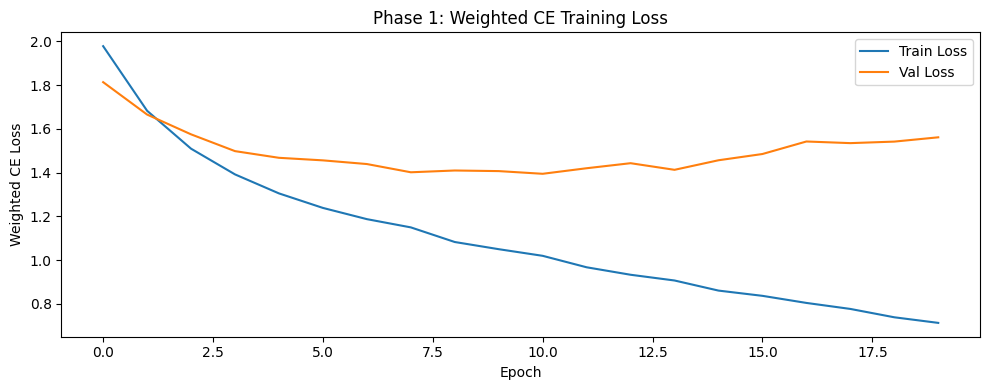

In [ ]:
history_p1 = train_phase1(cfg, model, tokenizer, adapter, train_data, eval_data, concept_vecs)

# Save phase 1 checkpoint
torch.save(adapter.state_dict(), cfg.adapter_save_path.replace(".pt", "_phase1.pt"))
print(f"Phase 1 adapter saved to: {cfg.adapter_save_path.replace('.pt', '_phase1.pt')}")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_p1["train_loss"], label="Train Loss")
ax.plot(history_p1["val_loss"],   label="Val Loss")
ax.set_title("Phase 1: Weighted CE Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted CE Loss")
ax.legend()
plt.tight_layout()
plt.show()


## Cell 10: Run Phase 2 (GRPO)


=== Phase 2: GRPO Training (5 epochs) ===
    G=4 completions per example, max_new_tokens=64
    Reward: 0.5*entity_presence + 0.5*ROUGE-L


GRPO Epoch 1/5:   0%|          | 0/1388 [00:00<?, ?it/s]

GRPO Epoch 1: loss=-1.1337  mean_reward=0.6573


GRPO Epoch 2/5:   0%|          | 0/1388 [00:00<?, ?it/s]

GRPO Epoch 2: loss=-0.9212  mean_reward=0.6798


...

GRPO Epoch 3: loss=-1.0050  mean_reward=0.6844


GRPO Epoch 4/5:   0%|          | 0/1388 [00:00<?, ?it/s]

GRPO Epoch 4: loss=-0.9944  mean_reward=0.6921


GRPO Epoch 5/5:   0%|          | 0/1388 [00:00<?, ?it/s]

GRPO Epoch 5: loss=-0.7857  mean_reward=0.6959
Final adapter saved to: results_v1/trained_adapters/adapter_meta-llama_Llama-3.1-8B-Instruct_L16_architecture3_hollistic.pt


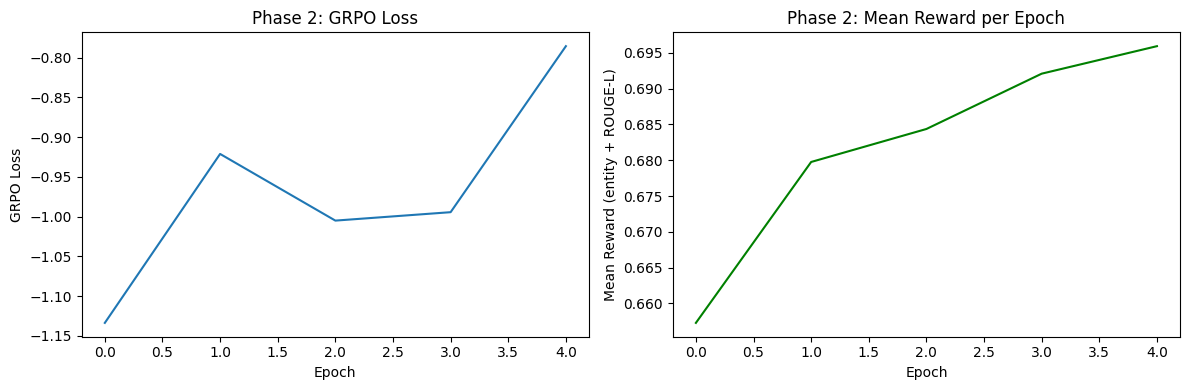

In [ ]:
history_p2 = train_phase2(cfg, model, tokenizer, adapter, train_data, eval_data, concept_vecs)

# Save final checkpoint
torch.save(adapter.state_dict(), cfg.adapter_save_path)
print(f"Final adapter saved to: {cfg.adapter_save_path}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_p2["grpo_loss"])
axes[0].set_title("Phase 2: GRPO Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("GRPO Loss")

axes[1].plot(history_p2["mean_reward"], color="green")
axes[1].set_title("Phase 2: Mean Reward per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Reward (entity + ROUGE-L)")

plt.tight_layout()
plt.show()


## Cell 11: Evaluation Function

*(Same as V1 — unchanged)*

In [ ]:
def evaluate_generation(cfg, model, tokenizer, adapter, eval_data, concept_vecs):
    print("\n--- Generating Responses with Injection ---")
    adapter = adapter.to(model.device, dtype=cfg.torch_dtype)
    adapter.eval()

    results = []

    for item in tqdm(eval_data, desc="Evaluating"):
        question      = item['question']
        target_answer = item['answer']
        entity_key    = item['entity_key']
        word_label    = item['entity_original']
        category      = item['category_key']

        msgs = [{"role": "user", "content": question}]
        prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs     = tokenizer(prompt_str, return_tensors="pt").to(model.device)

        vec     = concept_vecs[entity_key].to(model.device, dtype=cfg.torch_dtype)
        vec_in  = vec.unsqueeze(0)  # [1, H]

        with torch.no_grad():
            steering_vec = adapter(vec_in)  # [1, H]

        inject_idx = inputs['input_ids'].shape[1] - 1

        def gen_hook(module, args, output):
            hs = output[0] if isinstance(output, tuple) else output
            if hs.shape[1] > inject_idx:
                hs[:, inject_idx, :] = hs[:, inject_idx, :] + steering_vec
            return (hs,) + output[1:] if isinstance(output, tuple) else hs

        layer  = model.model.layers[cfg.injection_layer]
        handle = layer.register_forward_hook(gen_hook)

        try:
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=128,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id
                )
            generated_text = tokenizer.decode(
                outputs[0][inputs['input_ids'].shape[1]:],
                skip_special_tokens=True
            )
            results.append({
                "category":  category,
                "word":      word_label,
                "question":  question,
                "generated": generated_text,
                "expected":  target_answer,
            })
        finally:
            handle.remove()

    return pd.DataFrame(results)


## Cell 12: Evaluation on Validation Set

In [ ]:
df_eval = evaluate_generation(cfg, model, tokenizer, adapter, eval_data, concept_vecs)

eval_filename = f"architecture{cfg.architecture_id}/eval_results_L{cfg.injection_layer}_prompt{cfg.prompt_id}.csv"
eval_save_path = os.path.join(cfg.base_dir, eval_filename)
os.makedirs(os.path.dirname(eval_save_path), exist_ok=True)
df_eval.to_csv(eval_save_path, index=False)
print(f"Eval results saved to: {eval_save_path}")



--- Generating Responses with Injection ---


Evaluating:   0%|          | 0/279 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Eval results saved to: results_v1/architecture3/eval_results_L16_prompt1.csv


## Cell 13: Evaluation on Train Set

In [ ]:
print(f"--- Evaluating Training Set ({len(train_data)} examples) ---")
df_train_results = evaluate_generation(cfg, model, tokenizer, adapter, train_data, concept_vecs)

train_filename = f"architecture{cfg.architecture_id}/train_results_L{cfg.injection_layer}_prompt{cfg.prompt_id}.csv"
train_results_path = os.path.join(cfg.base_dir, train_filename)
os.makedirs(os.path.dirname(train_results_path), exist_ok=True)
df_train_results.to_csv(train_results_path, index=False)
print(f"Train results saved to: {train_results_path}")


--- Evaluating Training Set (1389 examples) ---

--- Generating Responses with Injection ---


Evaluating:   0%|          | 0/1389 [00:00<?, ?it/s]

Train results saved to: results_v1/architecture3/train_results_L16_prompt1.csv


## Cell 14: Evaluation on Test Set (Unseen Entities)

In [ ]:
test_data_df = pd.read_csv(os.path.join(cfg.base_dir, "Entities_QA_Test.csv"))
# Rename 'Word' -> 'Entity' to match train CSV column naming
test_data_df = test_data_df.rename(columns={"Word": "Entity"})


In [ ]:
print(f"--- Evaluating Test Set ({len(test_data_df)} examples) ---")

unique_words_test = list(test_data_df['Entity'].unique())
test_cfg          = copy.deepcopy(cfg)
test_cfg.mode     = "test"
test_cfg.words    = unique_words_test

concept_vecs_test = get_concept_vectors(test_cfg, model, tokenizer)

prepared_test_data = []
for idx, row in test_data_df.iterrows():
    word     = str(row['Entity'])
    question = str(row['Question'])
    answer   = str(row['Answer'])

    entity_key   = word.lower()              if test_cfg.use_lowercase else word
    category_key = "unknown_category"

    prepared_test_data.append({
        "category_key":    category_key,
        "entity_key":      entity_key,
        "entity_original": word,
        "question":        question,
        "answer":          answer
    })

df_test_results = evaluate_generation(test_cfg, model, tokenizer, adapter, prepared_test_data, concept_vecs_test)

test_filename  = f"architecture{test_cfg.architecture_id}/test_results_L{test_cfg.injection_layer}_prompt{test_cfg.prompt_id}.csv"
test_results_path = os.path.join(test_cfg.base_dir, test_filename)
os.makedirs(os.path.dirname(test_results_path), exist_ok=True)
df_test_results.to_csv(test_results_path, index=False)
print(f"Test results saved to: {test_results_path}")


--- Evaluating Test Set (154 examples) ---
Loading concept bank from: results_v1/learning_cache/test_concepts_meta-llama_Llama-3.1-8B-Instruct_L16_resid_post_norm_lower_prompt1.pt

--- Generating Responses with Injection ---


Evaluating:   0%|          | 0/154 [00:00<?, ?it/s]

Test results saved to: results_v1/architecture3/test_results_L16_prompt1.csv


## Cell 15: LLM-as-a-Judge

*(Same as V1 — configure ARCHITECTURE_DIRS to include 'architecture3')*

In [2]:
import os
import time
import json
import pandas as pd
from tqdm import tqdm
import google.generativeai as genai
from typing_extensions import TypedDict # For defining the JSON schema

# Define the exact JSON structure you expect the model to return
class EvaluationResult(TypedDict):
    contains_entity: bool
    contains_entity_explanation: str
    matches_reference: bool
    matches_reference_explanation: str

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

ARCHITECTURE_DIRS = ["architecture3"]
BASE_DIR   = "results_v1"
LAYER_ID   = 16
PROMPT_ID  = 1

FILE_PATTERNS = [
    "train_results_L{layer}_prompt{prompt}.csv",
    "eval_results_L{layer}_prompt{prompt}.csv",
    "test_results_L{layer}_prompt{prompt}.csv",
]

EVALUATION_PROMPT = """You are evaluating answers from a question-answering system.

**Context:**
- Entity: {word}
- Question: {question}
- Generated Answer: {generated}
- Reference Answer: {expected}

**Your Task:**
Evaluate the generated answer on two dimensions:

1. **Contains Entity**: Does the generated answer explicitly mention or reference the entity "{word}"?

2. **Matches Reference**: Does the generated answer convey the same core information as the reference answer?
   - They don't need to be word-for-word identical or even the same length.
   - A short answer (even just the entity name) is correct if it provides the key information asked by the question.
   - Focus on whether the generated answer would be considered a correct response to the question, using the reference answer as the source of truth.
   - For example, if the question asks "Which city..." and the reference says "The event happened in Paris", then a generated answer of just "Paris" should be considered a match."""

genai.configure(api_key=GEMINI_API_KEY)
judge_model = genai.GenerativeModel('gemini-2.5-flash')


def evaluate_single_row(row: dict) -> dict:
    prompt = EVALUATION_PROMPT.format(
        word=row['word'], question=row['question'],
        generated=row['generated'], expected=row['expected']
    )
    try:
        # Force JSON and enforce the schema!
        response = judge_model.generate_content(
            prompt,
            generation_config=genai.GenerationConfig(
                response_mime_type="application/json",
                response_schema=EvaluationResult
            )
        )

        # Fallback: Strip markdown just in case the model ignored the mime_type
        raw_text = response.text.strip()
        if raw_text.startswith("```json"):
            raw_text = raw_text[7:]
        if raw_text.startswith("```"):
            raw_text = raw_text[3:]
        if raw_text.endswith("```"):
            raw_text = raw_text[:-3]

        result = json.loads(raw_text.strip())

        return {
            "contains_entity":              result.get("contains_entity", False),
            "contains_entity_explanation":  result.get("contains_entity_explanation", ""),
            "matches_reference":            result.get("matches_reference", False),
            "matches_reference_explanation": result.get("matches_reference_explanation", ""),
        }
    except Exception as e:
        return {"contains_entity": False, "contains_entity_explanation": f"Error: {e}",
                "matches_reference": False, "matches_reference_explanation": f"Error: {e}"}


def evaluate_csv(csv_path: str, output_path: str = None) -> pd.DataFrame:
    if output_path is None:
        base, ext = os.path.splitext(csv_path)
        output_path = f"{base}_evaluated{ext}"
    print(f"Evaluating: {csv_path}")

    # Check if the file exists before reading
    if not os.path.exists(csv_path):
        print(f"  File not found: {csv_path}")
        return pd.DataFrame()

    df = pd.read_csv(csv_path)

    if os.path.exists(output_path):
        df_existing = pd.read_csv(output_path)
        if len(df_existing) == len(df) and 'contains_entity' in df_existing.columns:
            print(f"  Already evaluated — loading: {output_path}")
            return df_existing

    eval_results = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="LLM-as-judge"):
        result = evaluate_single_row(row.to_dict())
        eval_results.append(result)
        time.sleep(0.5)  # Rate limiting

    # Safely assign lists in case lengths got messed up (shouldn't happen, but safe)
    if len(eval_results) == len(df):
        for key in eval_results[0]:
            df[key] = [r.get(key) for r in eval_results]

        df.to_csv(output_path, index=False)
        print(f"  Saved: {output_path}")
    else:
        print("  Error: Mismatch in row counts.")

    return df


def run_all_evaluations():
    all_results = {}
    for arch_dir in ARCHITECTURE_DIRS:
        for pattern in FILE_PATTERNS:
            filename = pattern.format(layer=LAYER_ID, prompt=PROMPT_ID)
            csv_path = os.path.join(BASE_DIR, arch_dir, filename)
            if os.path.exists(csv_path):
                df = evaluate_csv(csv_path)
                if not df.empty:
                    all_results[f"{arch_dir}/{filename}"] = df
            else:
                print(f"Skipping (not found): {csv_path}")
    return all_results


results = run_all_evaluations()

print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
for name, df in results.items():
    if not df.empty and 'contains_entity' in df.columns:
        # We need to ensure values are boolean / numeric before computing mean
        # because earlier errors might have placed strings in there
        valid_contains = pd.to_numeric(df['contains_entity'], errors='coerce').dropna()
        valid_matches = pd.to_numeric(df['matches_reference'], errors='coerce').dropna()

        contains_pct = 100 * valid_contains.mean() if not valid_contains.empty else 0
        matches_pct  = 100 * valid_matches.mean() if not valid_matches.empty else 0

        print(f"{name}:")
        print(f"  Contains Entity:   {contains_pct:.1f}%")
        print(f"  Matches Reference: {matches_pct:.1f}%")
        print()

Evaluating: results_v1/architecture3/train_results_L16_prompt1.csv


LLM-as-judge: 100%|██████████| 1389/1389 [1:15:18<00:00,  3.25s/it]


  Saved: results_v1/architecture3/train_results_L16_prompt1_evaluated.csv
Evaluating: results_v1/architecture3/eval_results_L16_prompt1.csv


LLM-as-judge: 100%|██████████| 279/279 [14:43<00:00,  3.17s/it]


  Saved: results_v1/architecture3/eval_results_L16_prompt1_evaluated.csv
Evaluating: results_v1/architecture3/test_results_L16_prompt1.csv


LLM-as-judge: 100%|██████████| 154/154 [07:38<00:00,  2.97s/it]

  Saved: results_v1/architecture3/test_results_L16_prompt1_evaluated.csv

FINAL SUMMARY
architecture3/train_results_L16_prompt1.csv:
  Contains Entity:   97.3%
  Matches Reference: 83.2%

architecture3/eval_results_L16_prompt1.csv:
  Contains Entity:   90.7%
  Matches Reference: 77.1%

architecture3/test_results_L16_prompt1.csv:
  Contains Entity:   9.7%
  Matches Reference: 9.1%



## Cell 16: Results Visualization

*(Same as V1 — set ARCHITECTURES = ['architecture3'])*

Plot saved: results_v1/evaluation_plots/architecture3_train_L16_prompt1_evaluation.png


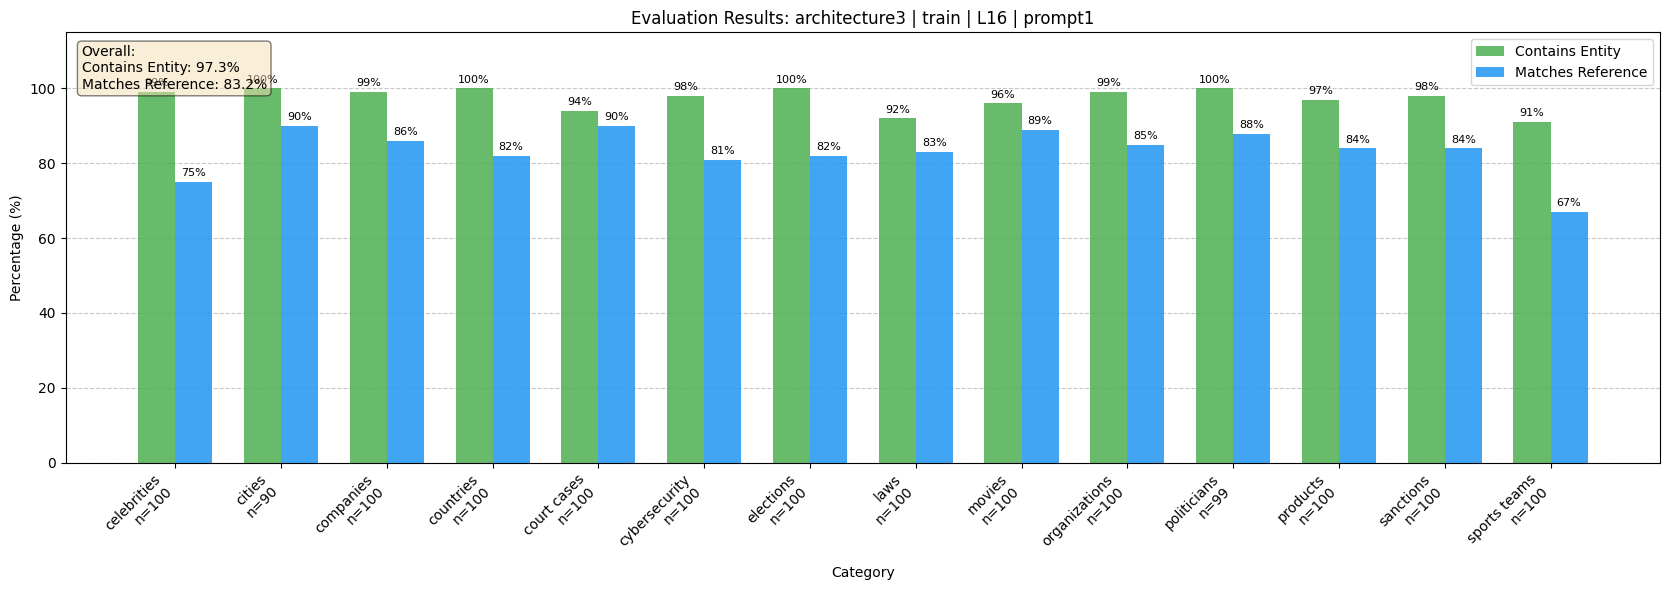

Plot saved: results_v1/evaluation_plots/architecture3_eval_L16_prompt1_evaluation.png


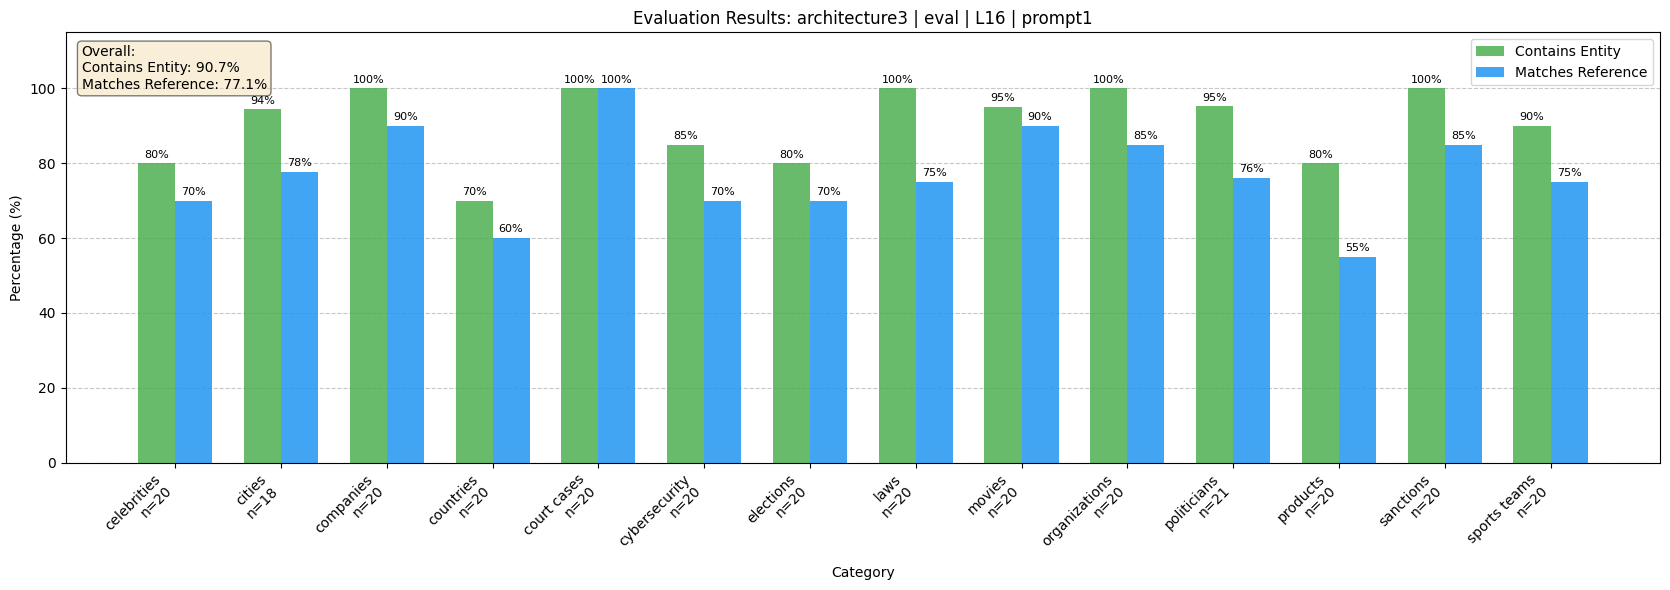

Plot saved: results_v1/evaluation_plots/architecture3_test_L16_prompt1_evaluation.png


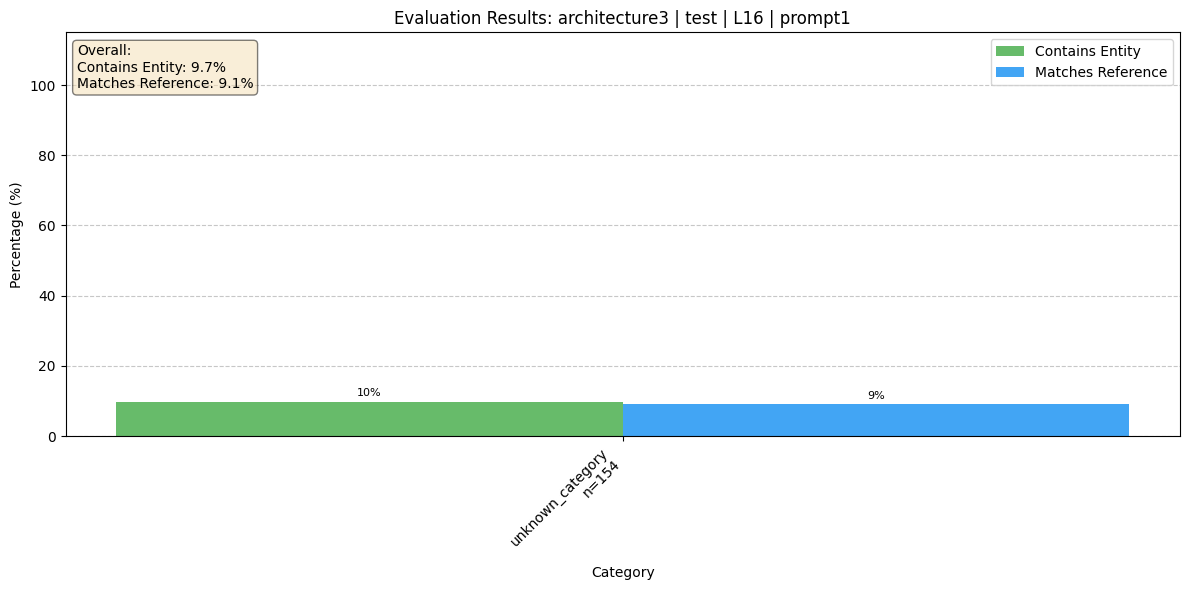

In [3]:
BASE_DIR         = "results_v1"
ARCHITECTURES    = ["architecture3"]
SPLITS           = ["train", "eval", "test"]
LAYER_ID         = 16
PROMPT_ID        = 1
PLOTS_OUTPUT_DIR = os.path.join(BASE_DIR, "evaluation_plots")


def plot_evaluation_by_category(
    architecture, split, layer, prompt,
    base_dir=BASE_DIR, save_plot=True, show_plot=True
):
    filename = f"{split}_results_L{layer}_prompt{prompt}_evaluated.csv"
    csv_path = os.path.join(base_dir, architecture, filename)

    if not os.path.exists(csv_path):
        print(f"File not found: {csv_path}")
        return None

    df = pd.read_csv(csv_path)
    if 'contains_entity' not in df.columns:
        print(f"Run LLM-as-a-judge first on: {csv_path}")
        return None

    category_metrics = df.groupby('category').agg(
        contains_entity_pct=('contains_entity',  lambda x: 100 * x.mean()),
        matches_reference_pct=('matches_reference', lambda x: 100 * x.mean()),
        count=('category', 'size')
    ).reset_index().sort_values('category')

    categories = category_metrics['category'].tolist()
    n = len(categories)
    x = np.arange(n)
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(12, n * 1.2), 6))
    bars1 = ax.bar(x - width/2, category_metrics['contains_entity_pct'],  width, label='Contains Entity',   color='#4CAF50', alpha=0.85)
    bars2 = ax.bar(x + width/2, category_metrics['matches_reference_pct'], width, label='Matches Reference', color='#2196F3', alpha=0.85)

    overall_ce = 100 * df['contains_entity'].mean()
    overall_mr = 100 * df['matches_reference'].mean()

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)

    counts = category_metrics['count'].tolist()
    ax.set_xticks(x)
    ax.set_xticklabels([f"{cat}\nn={cnt}" for cat, cnt in zip(categories, counts)], rotation=45, ha='right')
    ax.set_ylim(0, 115)
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('Category')
    ax.set_title(f'Evaluation Results: {architecture} | {split} | L{layer} | prompt{prompt}')
    ax.legend(loc='upper right')
    ax.text(0.01, 0.97,
            f'Overall:\nContains Entity: {overall_ce:.1f}%\nMatches Reference: {overall_mr:.1f}%',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    plt.tight_layout()

    if save_plot:
        os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)
        plot_path = os.path.join(PLOTS_OUTPUT_DIR, f"{architecture}_{split}_L{layer}_prompt{prompt}_evaluation.png")
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        print(f"Plot saved: {plot_path}")
    if show_plot:
        plt.show()
    plt.close()
    return category_metrics


for arch in ARCHITECTURES:
    for split in SPLITS:
        plot_evaluation_by_category(arch, split, LAYER_ID, PROMPT_ID)


# Cell 17: Baseline Test Performance

In [ ]:
# ==============================================================================
# BASELINE EVALUATION: No Adapter, Pure Model Generation on Test Set
# Self-contained cell — runs independently, no other cells needed.
# Saves results to: architecture_baseline/test_results_L16_prompt1.csv
# Run LLM-as-a-judge on it afterward to get Contains Entity / Matches Reference.
# ==============================================================================

import os
import json
import time
import torch
import pandas as pd
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from dotenv import load_dotenv
load_dotenv()
import google.generativeai as genai

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

# ── Config ────────────────────────────────────────────────────────────────────
MODEL_NAME   = "meta-llama/Llama-3.1-8B-Instruct"
BASE_DIR     = "results_v1"
TEST_CSV     = "results_v1/Entities_QA_Test.csv"
OUT_DIR      = os.path.join(BASE_DIR, "architecture_baseline")
OUT_PATH     = os.path.join(OUT_DIR, "test_results_L16_prompt1.csv")
MAX_NEW_TOKENS = 128

os.makedirs(OUT_DIR, exist_ok=True)

# ── Load model ────────────────────────────────────────────────────────────────
print("Loading model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = "right"
tokenizer.pad_token    = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.bfloat16
)
model.eval()
for param in model.parameters():
    param.requires_grad = False
print("Model loaded.")

# ── Load test data ────────────────────────────────────────────────────────────
test_df = pd.read_csv(TEST_CSV)
# Handle both 'Word' and 'Entity' column names
if 'Word' in test_df.columns and 'Entity' not in test_df.columns:
    test_df = test_df.rename(columns={'Word': 'Entity'})

print(f"Test examples: {len(test_df)}")

# ── Generate (no injection, no adapter) ──────────────────────────────────────
results = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Baseline generation"):
    entity   = str(row['Entity'])
    question = str(row['Question'])
    answer   = str(row['Answer'])

    msgs = [{"role": "user", "content": question}]
    prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt_str, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated = tokenizer.decode(
        output_ids[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )

    results.append({
        "category":  "unknown_category",
        "word":      entity,
        "question":  question,
        "generated": generated,
        "expected":  answer,
    })

df_results = pd.DataFrame(results)
df_results.to_csv(OUT_PATH, index=False)
print(f"\nBaseline results saved to: {OUT_PATH}")
print(f"Total examples: {len(df_results)}")
print("\nSample outputs:")
print(df_results[["word", "generated", "expected"]].head(5).to_string())

# ── LLM-as-a-judge ───────────────────────────────────────────────────────────
print("\n\nRunning LLM-as-a-judge...")

genai.configure(api_key=GEMINI_API_KEY)
judge_model = genai.GenerativeModel('gemini-2.5-flash')

EVALUATION_PROMPT = """You are evaluating answers from a question-answering system.

**Context:**
- Entity: {word}
- Question: {question}
- Generated Answer: {generated}
- Reference Answer: {expected}

**Your Task:**
Evaluate the generated answer on two dimensions:

1. **Contains Entity**: Does the generated answer explicitly mention or reference the entity "{word}"?

2. **Matches Reference**: Does the generated answer convey the same core information as the reference answer?
   - They don't need to be word-for-word identical or even the same length.
   - A short answer (even just the entity name) is correct if it provides the key information asked by the question.
   - Focus on whether the generated answer would be considered a correct response to the question, using the reference answer as the source of truth.

**Respond ONLY with valid JSON (no markdown, no extra text):**
{{"contains_entity": true or false, "contains_entity_explanation": "brief reason", "matches_reference": true or false, "matches_reference_explanation": "brief reason"}}"""


def evaluate_single_row(row: dict) -> dict:
    prompt = EVALUATION_PROMPT.format(
        word=row['word'], question=row['question'],
        generated=row['generated'], expected=row['expected']
    )
    try:
        response = judge_model.generate_content(prompt)
        result   = json.loads(response.text.strip())
        return {
            "contains_entity":               result.get("contains_entity", False),
            "contains_entity_explanation":   result.get("contains_entity_explanation", ""),
            "matches_reference":             result.get("matches_reference", False),
            "matches_reference_explanation": result.get("matches_reference_explanation", ""),
        }
    except Exception as e:
        return {
            "contains_entity": False, "contains_entity_explanation": f"Error: {e}",
            "matches_reference": False, "matches_reference_explanation": f"Error: {e}",
        }


eval_results = []
for _, row in tqdm(df_results.iterrows(), total=len(df_results), desc="LLM-as-judge"):
    eval_results.append(evaluate_single_row(row.to_dict()))
    time.sleep(0.5)

for key in eval_results[0]:
    df_results[key] = [r[key] for r in eval_results]

evaluated_path = OUT_PATH.replace(".csv", "_evaluated.csv")
df_results.to_csv(evaluated_path, index=False)
print(f"\nEvaluated results saved to: {evaluated_path}")

# ── Summary ───────────────────────────────────────────────────────────────────
contains_pct = 100 * df_results['contains_entity'].mean()
matches_pct  = 100 * df_results['matches_reference'].mean()

print(f"\n{'='*50}")
print("BASELINE RESULTS (No Adapter)")
print(f"{'='*50}")
print(f"  Contains Entity:   {contains_pct:.1f}%")
print(f"  Matches Reference: {matches_pct:.1f}%")
print(f"{'='*50}")
print("\nCompare against:")
print("  Architecture 1: Contains Entity=9.7%,  Matches Reference=7.1%")
print("  Architecture 3: Contains Entity=5.8%,  Matches Reference=5.8%")

Loading model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded.
Test examples: 154


Baseline generation:   0%|          | 0/154 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Baseline results saved to: results_v1/architecture_baseline/test_results_L16_prompt1.csv
Total examples: 154

Sample outputs:
             word                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                generated                                                      expected
0  Kendrick Lamar                                                                                                                                                                               

LLM-as-judge:   0%|          | 0/154 [00:00<?, ?it/s]

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1885.31ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1634.30ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1005.68ms



Evaluated results saved to: results_v1/architecture_baseline/test_results_L16_prompt1_evaluated.csv

BASELINE RESULTS (No Adapter)
  Contains Entity:   3.2%
  Matches Reference: 1.9%

Compare against:
  Architecture 1: Contains Entity=9.7%,  Matches Reference=7.1%
  Architecture 3: Contains Entity=5.8%,  Matches Reference=5.8%
